Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Comparison between the maximum-likelihood and the debiased estimator for the German tank problem.\
Topics and relevant videos: [Random sampling and the bias](https://youtu.be/iPTTn-hPg_0?si=oycOmm43MwWaNa3h)

Author: Carlos Fernandez-Granda

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
def run_german_tank_simulations(
    T: int = 100,
    sample_sizes: list[int] = [5, 10, 25, 50],
    num_simulations: int = 100_000,
    seed: int = 42,
) -> dict:
    """Runs Monte Carlo simulations for sampling without replacement and computes maximum likelihood and debiased estimates.
    """
    rng = np.random.default_rng(seed)
    sim_data = {}

    for n in sample_sizes:
        t_max = np.empty(num_simulations, dtype=int)

        # Draw n samples without replacement per trial
        for i in range(num_simulations):
            sample = rng.choice(np.arange(1, T + 1), size=n, replace=False)
            t_max[i] = sample.max()

        # Compute estimators
        T_ml = t_max
        T_debiased = ((n + 1) / n) * t_max - 1

        # Compute metrics
        rmse_ml = np.sqrt(np.mean((T_ml - T) ** 2))
        rmse_debiased = np.sqrt(np.mean((T_debiased - T) ** 2))
        
        # Save both raw samples and calculated metrics
        sim_data[n] = {
            "T_ml": T_ml,
            "T_debiased": T_debiased,
            "rmse_ml": rmse_ml,
            "rmse_debiased": rmse_debiased,
        }

    return sim_data


In [14]:
T_true = 100
sample_sizes = [5, 10, 25, 50]

# Run simulation step
simulation_data = run_german_tank_simulations(
    T=T_true, sample_sizes=sample_sizes
)

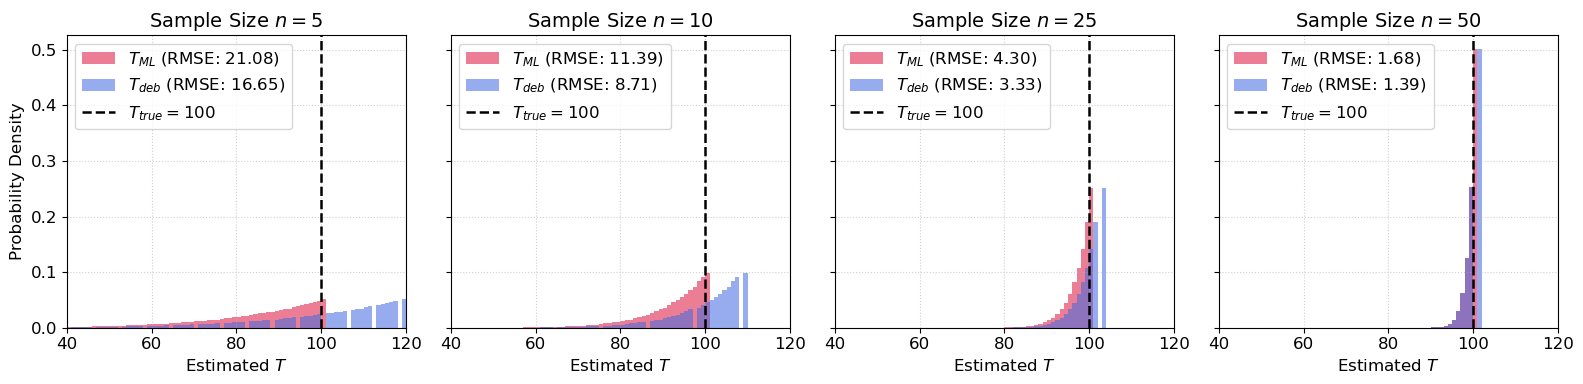

In [20]:
sample_sizes = list(simulation_data.keys())
num_plots = len(sample_sizes)

# Define your custom font size parameter
font_size = 12

# Set global Matplotlib parameters using font_size
plt.rcParams.update(
    {
        "font.size": font_size,  # Base font size
        "axes.labelsize": font_size,  # X and Y label size
        "axes.titlesize": font_size + 2,  # Title size
        "xtick.labelsize": font_size,  # X tick label size
        "ytick.labelsize": font_size,  # Y tick label size
        "legend.fontsize": font_size,  # Legend font size
        "figure.titlesize": font_size + 4,  # Figure title size
    }
)

figsize = (16, 4)
# Side-by-side layout (1 row x N columns)
fig, axes = plt.subplots(1, num_plots, figsize=figsize, sharey=True)

# Ensure axes is iterable even if only 1 plot is requested
if num_plots == 1:
    axes = [axes]

for ax, n in zip(axes, sample_sizes):
    data = simulation_data[n]
    T_ml = data["T_ml"]
    T_debiased = data["T_debiased"]

    # Set fixed x-axis limits for all subplots
    ax.set_xlim(40, 120)

    # Unified integer binning for precise alignment
    bins = np.arange(
        min(T_ml.min(), T_debiased.min()),
        max(T_ml.max(), T_debiased.max()) + 2,
        1,
    )

    # Plot ML distribution
    ax.hist(
        T_ml,
        bins=bins,
        alpha=0.55,
        density=True,
        color="crimson",
        label=f"$T_{{ML}}$ (RMSE: {data['rmse_ml']:.2f})",
    )

    # Plot Debiased distribution
    ax.hist(
        T_debiased,
        bins=bins,
        alpha=0.55,
        density=True,
        color="royalblue",
        label=f"$T_{{deb}}$ (RMSE: {data['rmse_debiased']:.2f})",
    )

    # True T vertical reference line
    ax.axvline(
        T_true,
        color="black",
        linestyle="--",
        linewidth=1.8,
        label=f"$T_{{true}} = {T_true}$",
    )

    ax.set_title(f"Sample Size $n = {n}$")
    ax.set_xlabel("Estimated $T$")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":", alpha=0.6)

axes[0].set_ylabel("Probability Density")
plt.tight_layout()
plt.show()

